In [11]:
#This is testing a random forest regression model
import pandas as pd
import numpy as np
import math

#Imports for RF regession
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor #Regression version of Random Forest
from sklearn.metrics import mean_squared_error, r2_score

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Imports for model dump
import joblib

#Define dataset
health_db = pd.read_csv("datasets/normalized_health_dataset.csv")

In [12]:
health_db.info() #Show column values
print("Rating Min:", health_db["mental_health_rating"].min())
print("Rating Max:", health_db["mental_health_rating"].max())
print("Rating Average:", health_db["mental_health_rating"].mean())

<class 'pandas.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   daily_study_hours              1004 non-null   float64
 1   social_media_hours             1004 non-null   float64
 2   tv_hours                       1004 non-null   float64
 3   part_time_job                  1004 non-null   int64  
 4   sleep_hours                    1004 non-null   float64
 5   diet_quality                   1004 non-null   int64  
 6   exercise_frequency_weekly      1004 non-null   float64
 7   mental_health_rating           1004 non-null   float64
 8   extracurricular_participation  1004 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 70.7 KB
Rating Min: 0.312065631808
Rating Max: 0.893616557734
Rating Average: 0.6104725664336115


In [15]:
health_db.head(5) #Show dataset structure
#ENCODING STRUCTURE (Here until I figure out how to display it) (FIXED)
#Part time job: No = 0, Yes = 1 
#Diet Quality: Fair = 1, Good = 2, Poor = 0
#Extracurricular participation: No = 0, Yes = 1

,daily_study_hours,social_media_hours,tv_hours,part_time_job,sleep_hours,diet_quality,exercise_frequency_weekly,mental_health_rating,extracurricular_participation
0,1.4,3.1,1.3,0,8.0,0,1.0,0.551428,0
1,0.0,1.2,1.1,0,8.0,1,6.0,0.863796,1
2,6.9,2.8,2.3,0,4.6,2,6.0,0.614809,0
3,1.0,3.9,1.0,0,9.2,0,4.0,0.724043,1
4,5.0,4.4,0.5,0,4.9,1,3.0,0.474172,0


<Axes: >

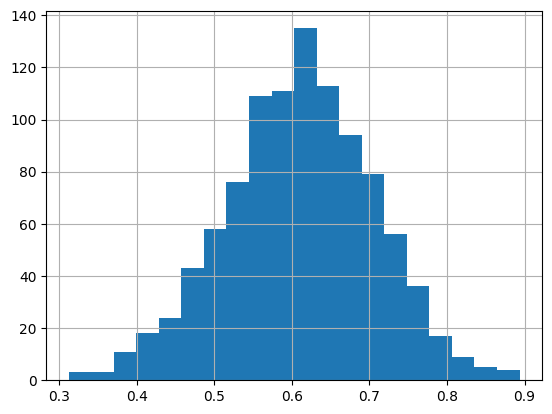

In [20]:
#View rating distribution
health_db["mental_health_rating"].hist(bins=20)

In [7]:
#Drops rows that contain missing values under mental_health_rating
health_db = health_db.dropna(subset = ["mental_health_rating"])

#Defining X and y
X = health_db[["daily_study_hours", "social_media_hours", "tv_hours", "part_time_job", 
              "sleep_hours", "diet_quality", "exercise_frequency_weekly", "extracurricular_participation"]]
y = health_db["mental_health_rating"] #Target column

#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Defining model
model = RandomForestRegressor(
    n_estimators = 200, 
    max_depth = 10, #Limits tree complexity through limiting splits
    min_samples_leaf = 4, #Each prediction has at least #num data points
    random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
#MSE and R2 report
mse = mean_squared_error(y_test, y_pred) #How off the predictions are on average
r2 = r2_score(y_test, y_pred) #Amount of structures the model understands in the data
rmse = (math.sqrt(mse)) #Root MSE. Calculates average of how off predictions are. 


#Print MSE, R2, and RSME
print(f"Mean Squared Error:", mse) #Low MSE is good, but not too low.
print(f"R2 Score:", r2) #High value is good, but not too high.
print(f"RSME:", rmse) #Average of predictions to true values


Mean Squared Error: 0.0010975716536254729
R2 Score: 0.8807579830324502
RSME: 0.033129618977970045


In [9]:
#Code to determine how close the model's predictions are
#Target value has max of 1 and min of 0. 
#Ex: 0.68 target value and within 0.1 means that prediction is between 0.58-0.78
range_1 = np.mean(np.abs(y_test - y_pred) <= 1) 
range_2 = np.mean(np.abs(y_test - y_pred) <= .25)
range_3 = np.mean(np.abs(y_test - y_pred) <= .1)
range_4 = np.mean(np.abs(y_test - y_pred) <= .08)
range_5 = np.mean(np.abs(y_test - y_pred) <= .05)
range_6 = np.mean(np.abs(y_test - y_pred) <= .04)
range_7 = np.mean(np.abs(y_test - y_pred) <= .03)
range_8 = np.mean(np.abs(y_test - y_pred) <= .02)
range_9 = np.mean(np.abs(y_test - y_pred) <= .01)
range_10 = np.mean(np.abs(y_test - y_pred) <= .005)

#Much improved results!
print("Within 1:", range_1,
"--Within .25:", range_2,
"--Within .1:", range_3,
"--Within .08:", range_4,
"--Within .05:", range_5,
"--Within .04:", range_6,
"--Within .03:", range_7,
"--Within .02:", range_8,
"--Within .01:", range_9,
"--Within 0.005:", range_10)

Within 1: 1.0 --Within .25: 1.0 --Within .1: 0.9950248756218906 --Within .08: 0.9850746268656716 --Within .05: 0.8656716417910447 --Within .04: 0.7910447761194029 --Within .03: 0.6119402985074627 --Within .02: 0.4925373134328358 --Within .01: 0.22885572139303484 --Within 0.005: 0.1044776119402985


In [10]:
#Trasforming model to pkl
#Only run when updating model
joblib.dump(model, "mental_rating_model.pkl") 




['mental_rating_model.pkl']